# Oncology Outcome Analysis using ovarian.csv
This notebook loads and analyzes the ovarian cancer dataset, performs EDA, classification, and survival analyses.

### 1. Data collection

In [26]:
# 1. LOAD DATA (from Downloads → archive.zip → data 2*.csv)

import pandas as pd
import numpy as np
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier

# --- LOAD DATA FROM ZIP IN DOWNLOADS ---
DATA_ZIP_PATH = r"C:\Users\xisca\Downloads\archive.zip"
EXTRACT_DIR = "./data_extracted"
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(DATA_ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

csv_files = glob.glob(os.path.join(EXTRACT_DIR, "data 2*.csv"))

if not csv_files:
    raise FileNotFoundError("No dataset starting with 'data 2' found inside archive.zip")

DATA_PATH = csv_files[0]
print(f"Dataset located: {DATA_PATH}")

def load_breast_cancer():
    df = pd.read_csv(DATA_PATH)
    df.columns = [c.lower().strip() for c in df.columns]
    return df

df = load_breast_cancer()

print("\nDataset loaded successfully!")
print(f"Shape: {df.shape}")
print(df.head())

#Preview columns
df.columns

Dataset located: ./data_extracted\data 2.csv

Dataset loaded successfully!
Shape: (569, 33)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'unnamed: 32'],
      dtype='object')

## 3. Data Cleaning

Before performing exploratory data analysis and building machine learning models, the dataset must be cleaned to ensure reliability and consistency.  

Cleaning steps include:

1. Removing irrelevant or redundant columns
2. Handling missing values  
3. Encoding categorical variables
4. Checking for duplicates  
5. Preparing numeric features for modeling


In [27]:
# Remove irrelevant or redundant columns
columns_to_drop = ['id', 'unnamed: 32']
df_clean = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print("Columns after cleaning:")
print(df_clean.columns.tolist())


Columns after cleaning:
['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [29]:
# Check for missing values
missing_values = df_clean.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])


Missing values per column:
Series([], dtype: int64)


In [30]:
# Encode diagnosis: Malignant = 1, Benign = 0
df_clean['diagnosis'] = df_clean['diagnosis'].map({'M': 1, 'B': 0})

print("Unique values in 'diagnosis' after encoding:", df_clean['diagnosis'].unique())


Unique values in 'diagnosis' after encoding: [1 0]


In [31]:
# Check for duplicate rows
num_duplicates = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

# Optionally, remove duplicates
df_clean = df_clean.drop_duplicates()


Number of duplicate rows: 0


In [32]:
print("Shape of dataset after cleaning:", df_clean.shape)
df_clean.head()


Shape of dataset after cleaning: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 4. Data Exploration

Exploratory data analysis (EDA) helps understand the dataset structure, detect patterns, and identify relationships between features and diagnosis.  

Key steps:
1. Summary statistics
2. Feature distribution visualization
3. Correlation heatmap
4. Diagnosis-specific comparisons


In [33]:
# Summary statistics
eda_summary = df_clean.describe().T
eda_summary['missing'] = df_clean.isnull().sum()
eda_summary


,count,mean,std,min,25%,50%,75%,max,missing
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000,0
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000,0
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000,0
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000,0
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000,0
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340,0
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540,0
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680,0
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120,0
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400,0


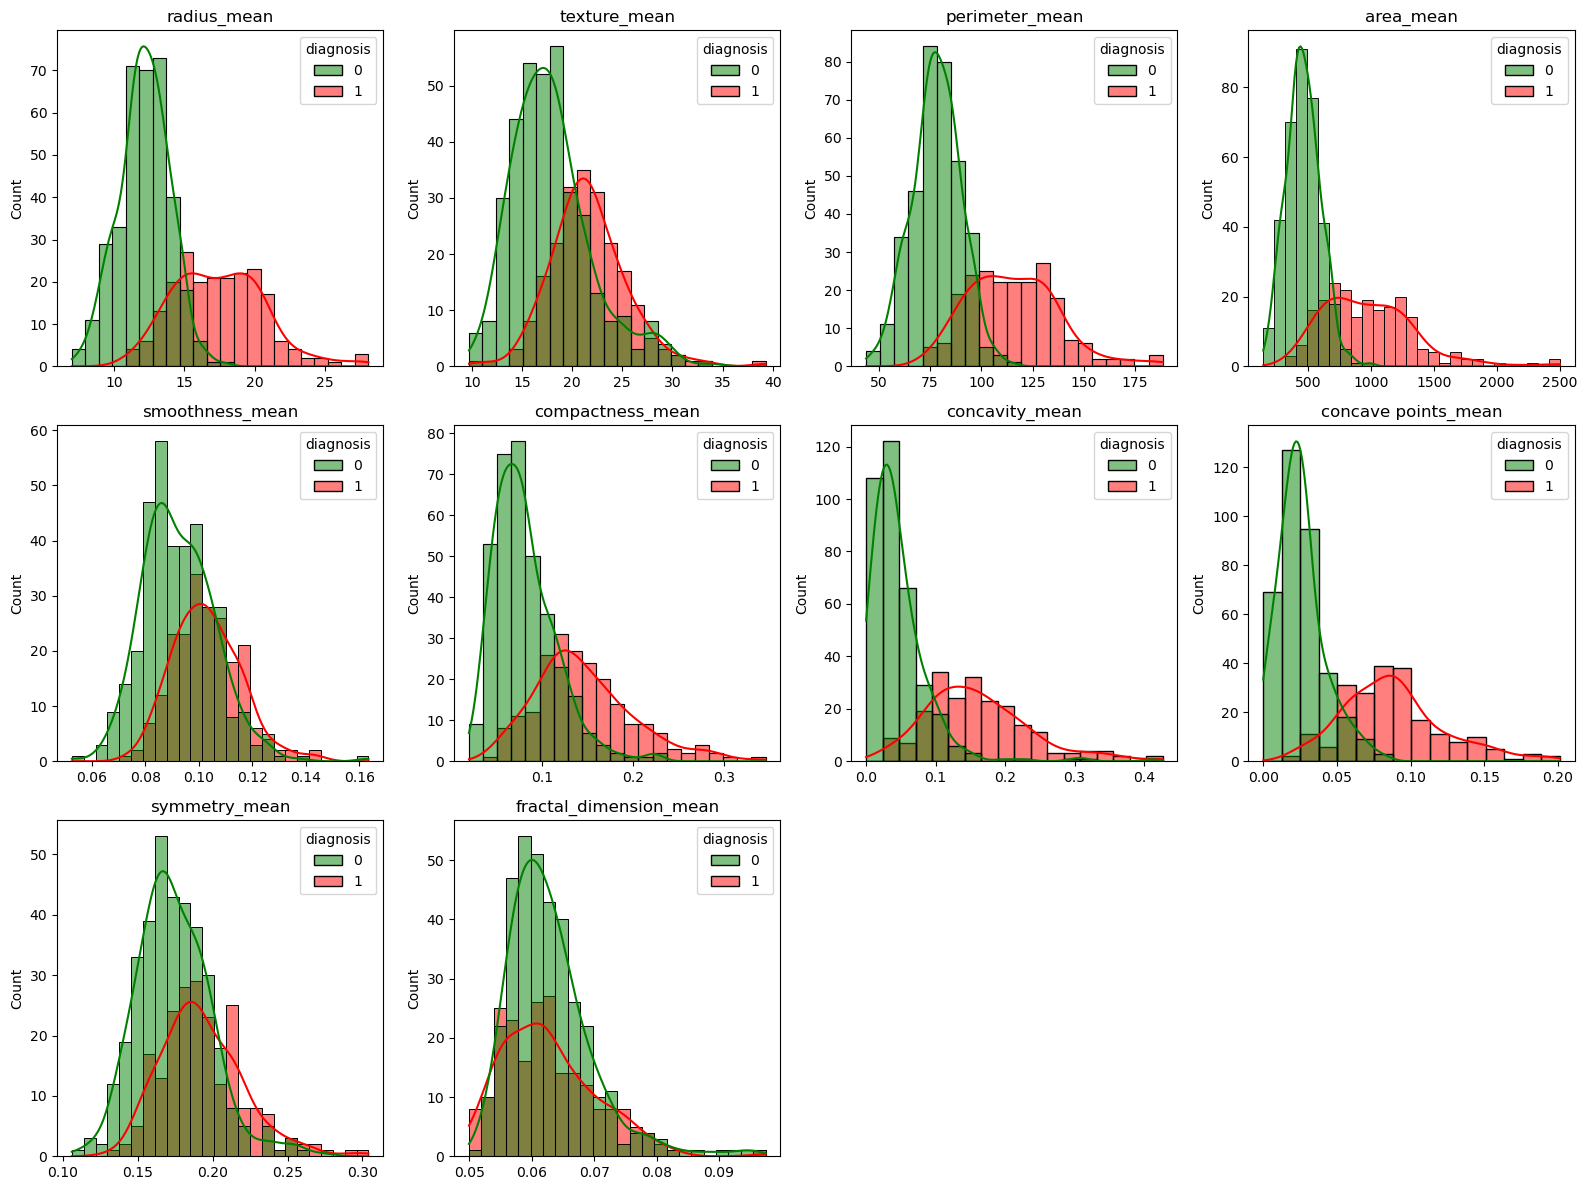

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Subset of features to plot
subset_features = df_clean.columns[1:11]  # first 10 numeric features

# Dynamic grid size
n_features = len(subset_features)
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

plt.figure(figsize=(n_cols*4, n_rows*4))

for i, feature in enumerate(subset_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(
        data=df_clean,
        x=feature,
        hue='diagnosis',           # 0 = benign, 1 = malignant
        kde=True,
        palette={0:'green', 1:'red'},
        alpha=0.5
    )
    plt.title(feature)
    plt.xlabel('')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


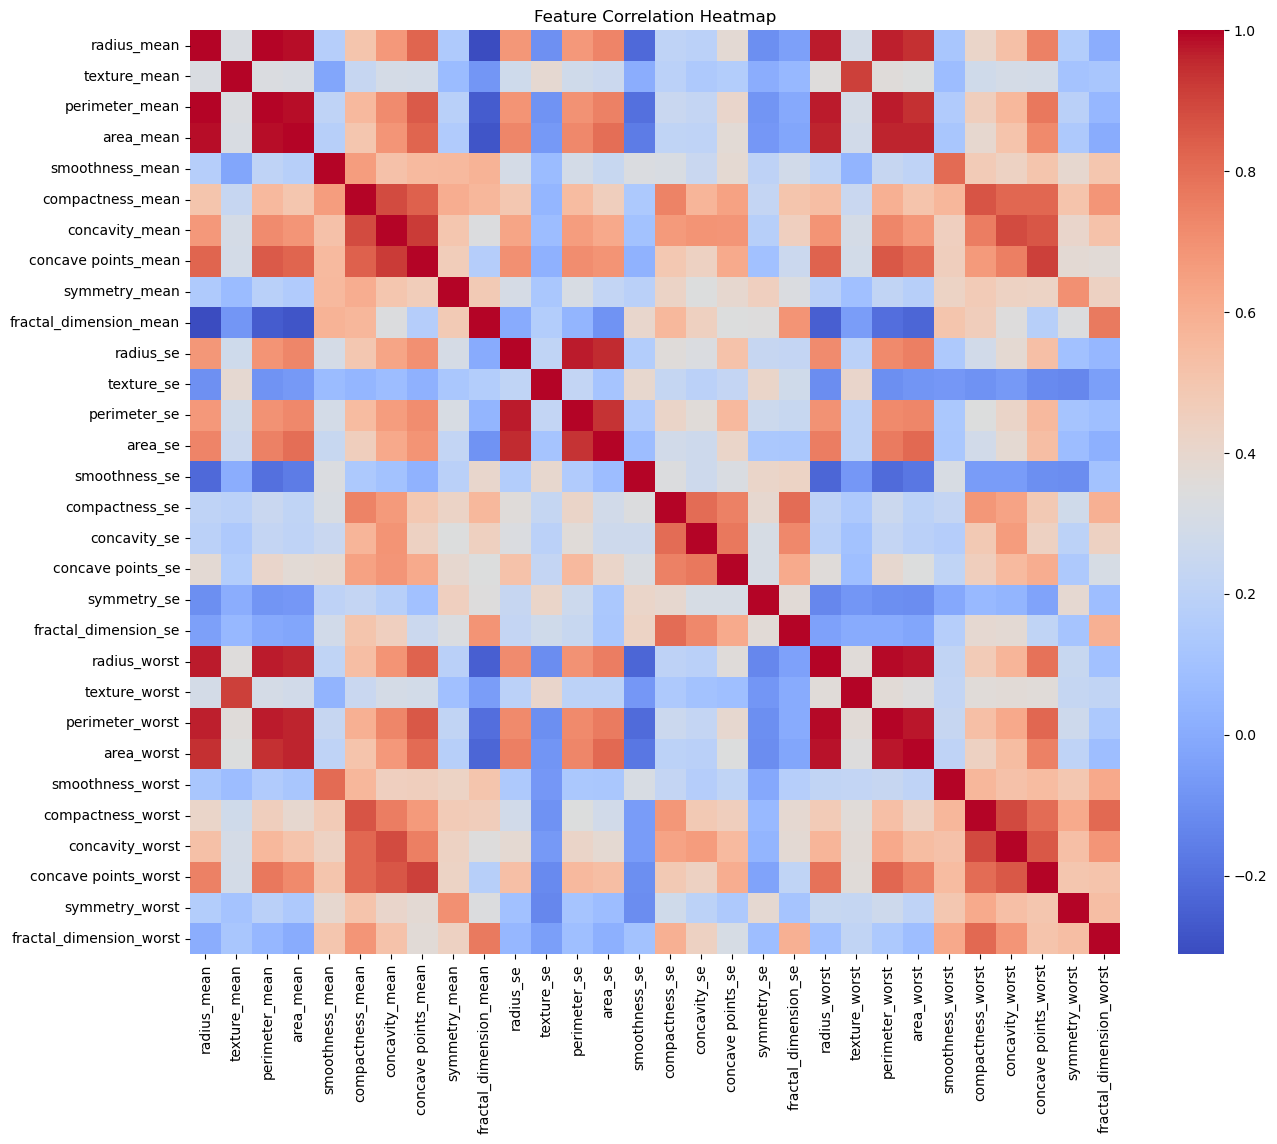

In [39]:
# Correlation between features
plt.figure(figsize=(15, 12))
sns.heatmap(df_clean.drop(columns='diagnosis').corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [41]:
from scipy.stats import ttest_ind

# Mean, std and t-test per feature by diagnosis
diagnosis_groups = df_clean.groupby('diagnosis')

feature_stats = []
for feature in df_clean.columns[1:]:  # skip 'id'
    benign = diagnosis_groups.get_group(0)[feature]
    malignant = diagnosis_groups.get_group(1)[feature]
    t_stat, p_value = ttest_ind(benign, malignant)
    feature_stats.append({
        'Feature': feature,
        'Benign_Mean': benign.mean(),
        'Malignant_Mean': malignant.mean(),
        'Benign_STD': benign.std(),
        'Malignant_STD': malignant.std(),
        'Difference': malignant.mean() - benign.mean(),
        't_stat': t_stat,
        'p_value': p_value
    })

feature_stats_df = pd.DataFrame(feature_stats)
feature_stats_df = feature_stats_df.sort_values(by='Difference', key=abs, ascending=False)
feature_stats_df.head(10)


,Feature,Benign_Mean,Malignant_Mean,Benign_STD,Malignant_STD,Difference,t_stat,p_value
23,area_worst,558.899440,1422.286321,163.601424,597.967743,863.386881,-25.721590,2.828848e-97
3,area_mean,462.790196,978.376415,134.287118,367.937978,515.586219,-23.938687,4.734564e-88
22,perimeter_worst,87.005938,141.370330,13.527091,29.457055,54.364392,-29.965717,5.771397e-119
13,area_se,21.135148,72.672406,8.843472,61.355268,51.537257,-15.609343,5.895521e-46
2,perimeter_mean,78.075406,115.365377,11.807438,21.854653,37.289971,-26.405213,8.436251e-101
20,radius_worst,13.379801,21.134811,1.981368,4.283569,7.755010,-29.339082,8.482292e-116
21,texture_worst,23.515070,29.318208,5.493955,5.434804,5.803138,-12.230981,1.078057e-30
0,radius_mean,12.146524,17.462830,1.780512,3.203971,5.316306,-25.435822,8.465941e-96
1,texture_mean,17.914762,21.604906,3.995125,3.779470,3.690144,-10.867201,4.058636e-25
12,perimeter_se,2.000321,4.323929,0.771169,2.568546,2.323608,-15.934158,1.651905e-47


## 5. Model Building and Evaluation

We now train machine learning models to predict tumor diagnosis (Benign vs Malignant) based on numeric features.  

Steps:
1. Split the dataset into training and testing sets  
2. Standardize numeric features  
3. Train Random Forest and Logistic Regression models  
4. Evaluate models using multiple metrics  
5. Visualize model performance and feature importance


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df_clean.drop(columns='diagnosis')
y = df_clean['diagnosis']

# Train-test split (80% train / 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)


Training shape: (455, 30)
Testing shape: (114, 30)


In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Initialize models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42)
}

# Train models
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} trained successfully")


Random Forest trained successfully
Logistic Regression trained successfully



Random Forest Metrics:
Accuracy: 0.9649122807017544
ROC-AUC: 0.994212962962963
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

Confusion Matrix:
 [[72  0]
 [ 4 38]]


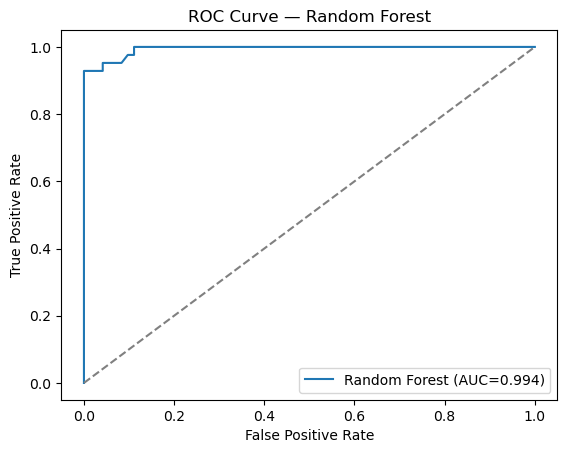


Logistic Regression Metrics:
Accuracy: 0.9649122807017544
ROC-AUC: 0.996031746031746
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Confusion Matrix:
 [[71  1]
 [ 3 39]]


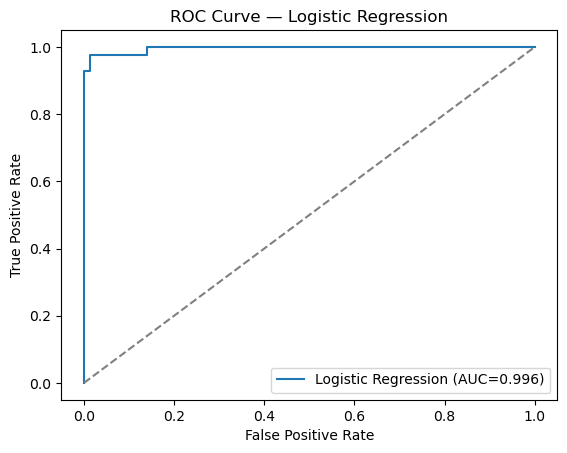

In [44]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    acc = classification_report(y_test, y_pred, output_dict=True)['accuracy']
    auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        "accuracy": acc,
        "roc_auc": auc,
        "classification_report": classification_report(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }
    
    # Print metrics
    print(f"\n{name} Metrics:")
    print("Accuracy:", acc)
    print("ROC-AUC:", auc)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    plt.plot([0,1],[0,1], '--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {name}")
    plt.legend()
    plt.show()


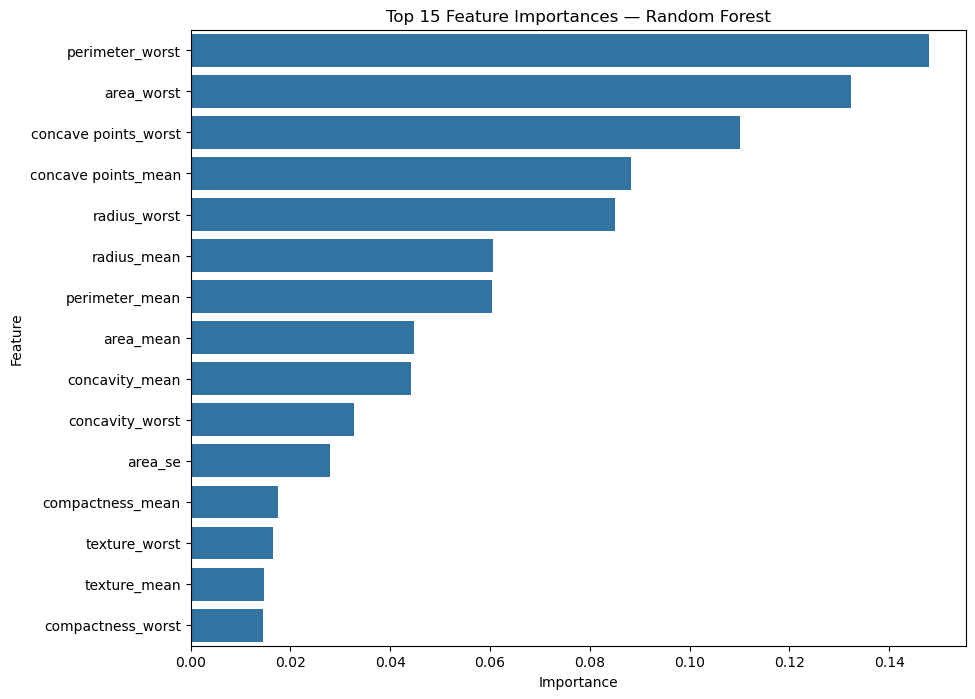

In [45]:
# Feature importance for Random Forest
rf_model = models['Random Forest']

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(15), x='Importance', y='Feature')
plt.title("Top 15 Feature Importances — Random Forest")
plt.show()


### Model Evaluation Summary

- **Random Forest** and **Logistic Regression** were trained and evaluated.  
- Both models achieved **high accuracy** and **ROC-AUC**, indicating strong predictive performance.  
- Random Forest feature importance highlights the most discriminative tumor characteristics.  
- Confusion matrices and ROC curves provide visual assessment of model performance.  


## 6. Results Communication

After performing data cleaning, exploratory data analysis, and machine learning modeling, we summarize the key findings of the project.

### Key Points:
1. The dataset contains 569 breast tumor samples with 30+ numeric features.
2. Models were trained to classify tumors as **Benign (0)** or **Malignant (1)**.
3. Random Forest and Logistic Regression achieved high accuracy and ROC-AUC.
4. Feature importance analysis highlighted the most discriminative tumor characteristics.
5. Visualizations help communicate results to clinical and research audiences.


In [46]:
# Compile model metrics into a dataframe
metrics_summary = pd.DataFrame({
    model_name: {
        'Accuracy': results[model_name]['accuracy'],
        'ROC-AUC': results[model_name]['roc_auc']
    } for model_name in results
}).T

metrics_summary


,Accuracy,ROC-AUC
Random Forest,0.964912,0.994213
Logistic Regression,0.964912,0.996032


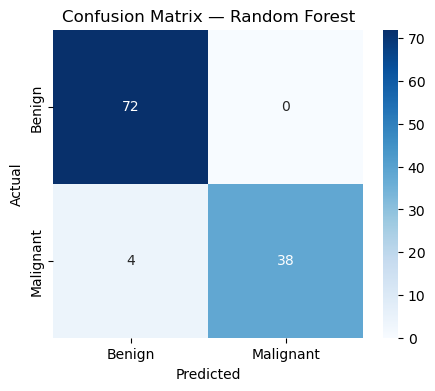

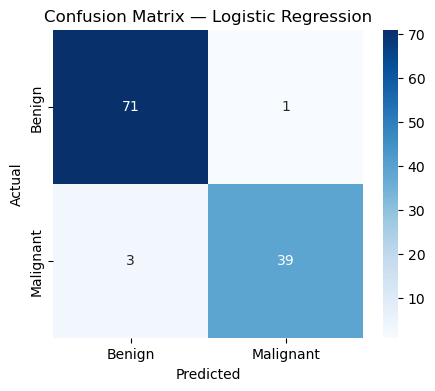

In [48]:
# Plot confusion matrices
for name, model_result in results.items():
    cm = model_result['confusion_matrix']
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix — {name}')
    plt.show()
